In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [2]:
df_loan=pd.read_csv(r"C:\Users\KESHAV ARORA\Downloads\loanapproval.csv")

In [3]:
df_loan.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [4]:
df_loan.shape #it has 1000 rows and 11 columns

(1000, 11)

In [5]:
df_loan.info() #no missing values here

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [7]:
df_loan.drop('applicant_id',axis=1,inplace=True) #we dropped the applicant id

In [8]:
df_loan.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [9]:
df_loan.describe()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [11]:
df_loan.isna().sum() #as mentioned no missing values

age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

## EDA

In [12]:
df_loan.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


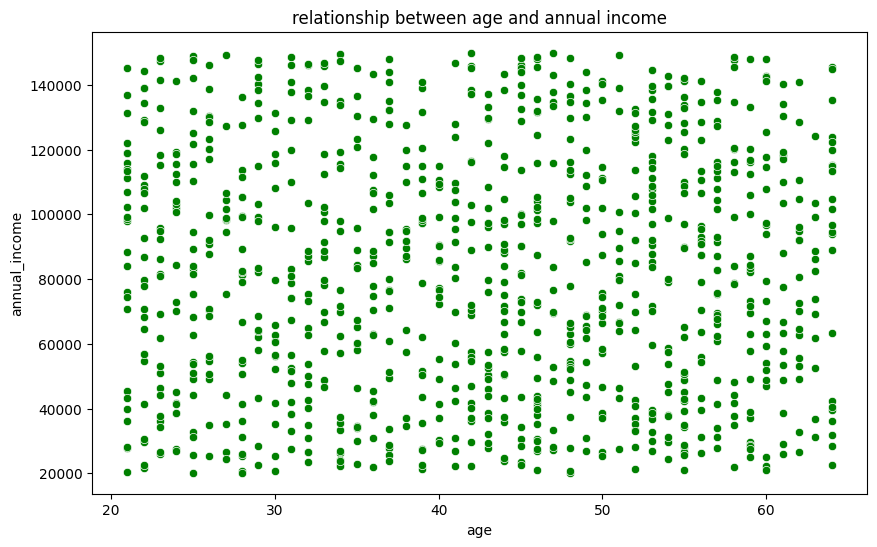

In [13]:
# I want to see the relation between age and annual_income
plt.figure(figsize=(10,6))
sns.scatterplot(x='age',y='annual_income',data=df_loan,color='green')
plt.title("relationship between age and annual income")
plt.show()

In [15]:
df_loan[['age','annual_income']].corr() #from both of this we can see that there is no inherent relation between age and annual income

,age,annual_income
age,1.000000,0.002591
annual_income,0.002591,1.000000


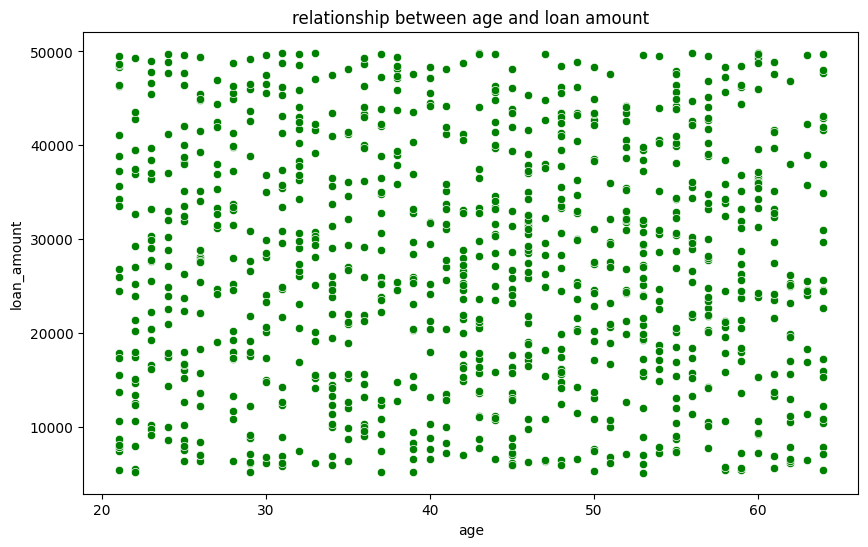

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age',y='loan_amount',data=df_loan,color='green')
plt.title("relationship between age and loan amount")
plt.show()

In [19]:
df_loan[['age','loan_amount']].corr() #from both of this we can see that there is no inherent relation between age and loan_amount

,age,loan_amount
age,1.000000,0.000235
loan_amount,0.000235,1.000000


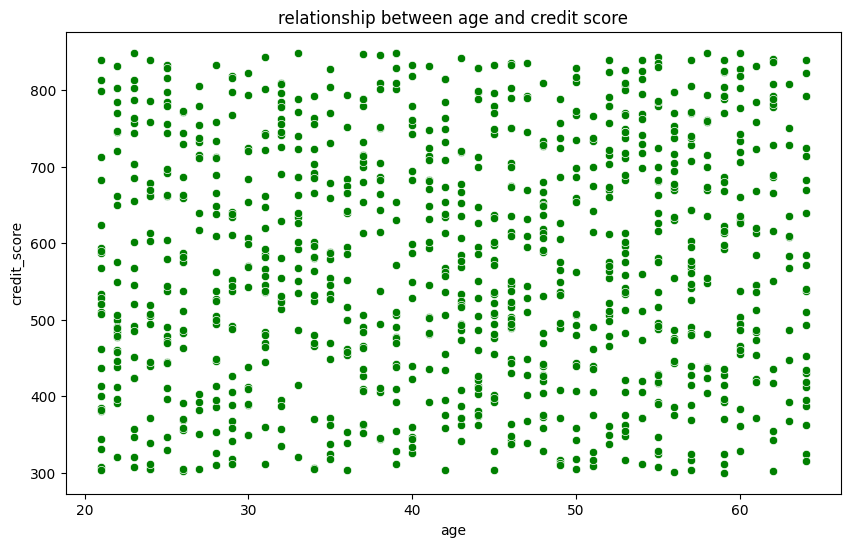

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age',y='credit_score',data=df_loan,color='green')
plt.title("relationship between age and credit score")
plt.show()

In [27]:
df_loan.select_dtypes(include='number').corr()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
age,1.000000,0.002591,0.000235,0.052769,-0.031510,0.063977,0.020984
annual_income,0.002591,1.000000,-0.024862,0.016921,-0.016445,-0.010745,0.176453
loan_amount,0.000235,-0.024862,1.000000,0.044939,0.037140,-0.012043,0.015355
credit_score,0.052769,0.016921,0.044939,1.000000,-0.067063,0.017398,0.351167
num_dependents,-0.031510,-0.016445,0.037140,-0.067063,1.000000,0.046405,-0.365317
existing_loans_count,0.063977,-0.010745,-0.012043,0.017398,0.046405,1.000000,-0.324236
loan_approved,0.020984,0.176453,0.015355,0.351167,-0.365317,-0.324236,1.000000


<Axes: >

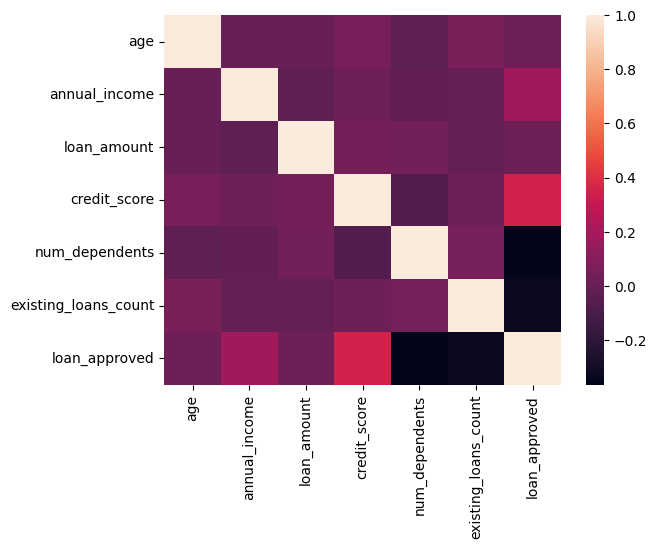

In [26]:
sns.heatmap(df_loan.select_dtypes(include='number').corr())

<Axes: xlabel='gender', ylabel='loan_approved'>

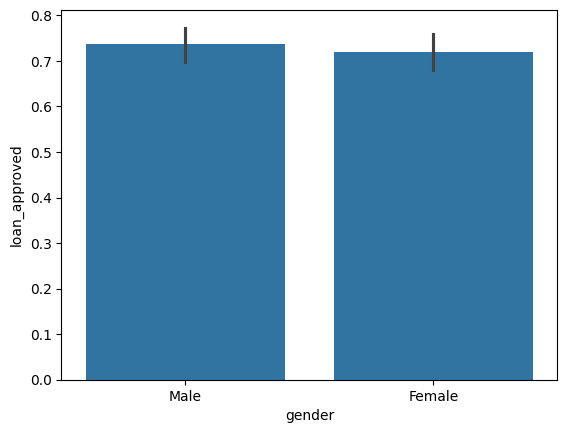

In [32]:
#we won't get much by bivariate analysis
sns.barplot(x=df_loan['gender'],y=df_loan["loan_approved"]) #more times loan has been approved to males rather than female but it is almost equal

<Axes: xlabel='gender', ylabel='count'>

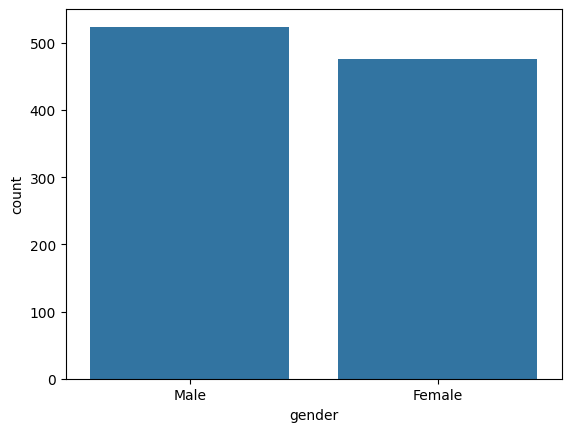

In [35]:
sns.countplot(x=df_loan['gender']) #but more number of times it is males who apply for loans

<Axes: xlabel='gender', ylabel='credit_score'>

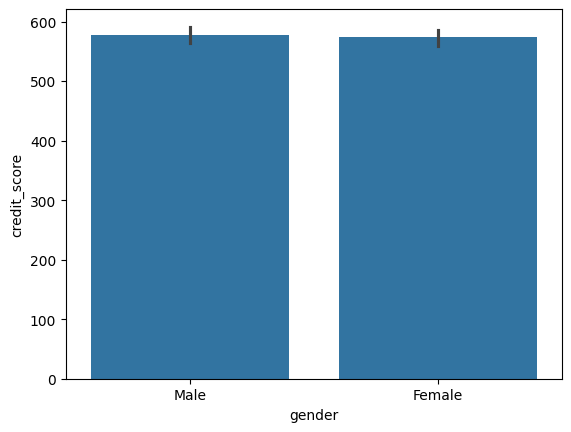

In [36]:
sns.barplot(x=df_loan['gender'],y=df_loan["credit_score"]) #Males have slightly better credit score than females.

<Axes: xlabel='gender', ylabel='annual_income'>

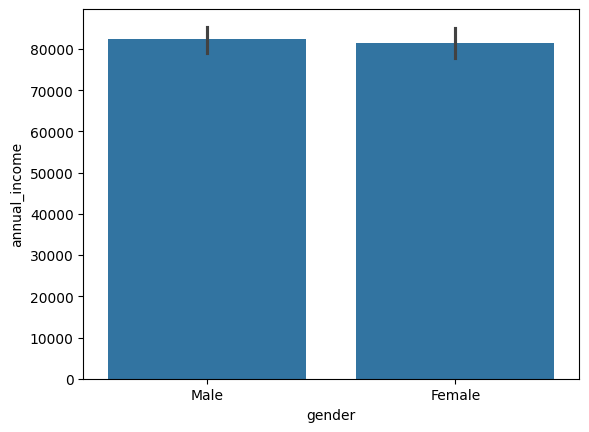

In [37]:
sns.barplot(x=df_loan['gender'],y=df_loan["annual_income"])

In [38]:
df_loan.groupby('gender')['annual_income'].mean() # on an avg males have higher salaries than females

gender
Female    81542.813025
Male      82363.727099
Name: annual_income, dtype: float64

<Axes: xlabel='gender', ylabel='loan_amount'>

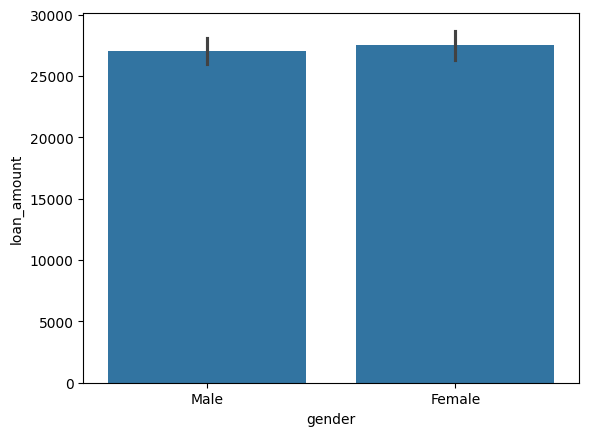

In [39]:
sns.barplot(x=df_loan['gender'],y=df_loan["loan_amount"]) #females get more loan amount

In [41]:
df_loan.columns

Index(['age', 'gender', 'marital_status', 'annual_income', 'loan_amount',
       'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='object')

<Axes: xlabel='gender', ylabel='count'>

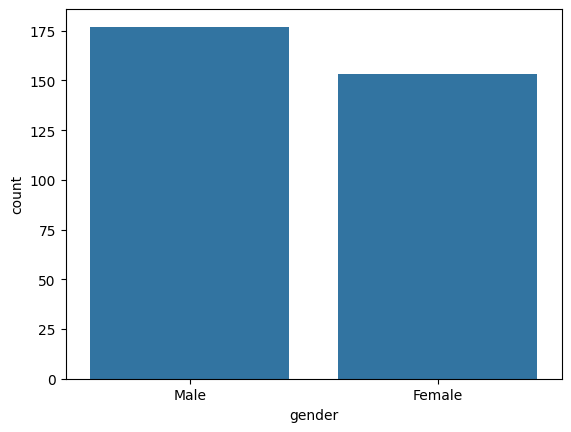

In [57]:
sns.countplot(x='gender', data=df_loan[df_loan['employment_status']=='Unemployed']) #more males are unemployed than females

<Axes: xlabel='marital_status', ylabel='loan_approved'>

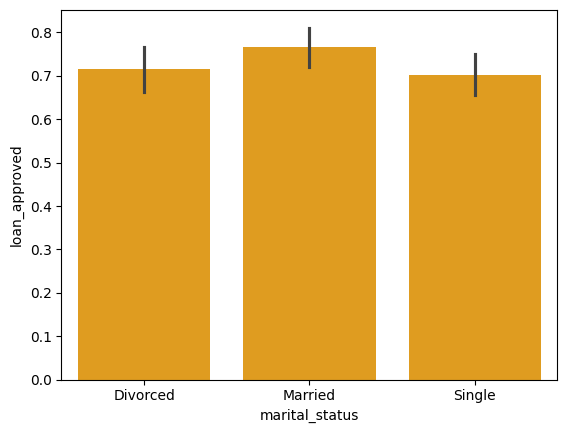

In [62]:
sns.barplot(x=df_loan['marital_status'],y=df_loan['loan_approved'],color='orange')

<Axes: xlabel='existing_loans_count', ylabel='count'>

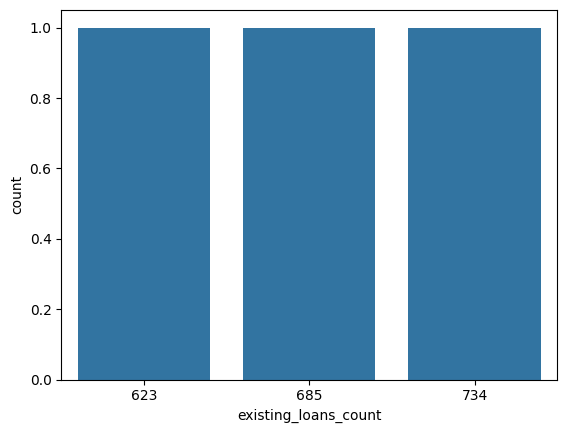

In [78]:
sns.countplot(x=df_loan.groupby('marital_status')['existing_loans_count'].sum())

## Handling outliers

<Axes: >

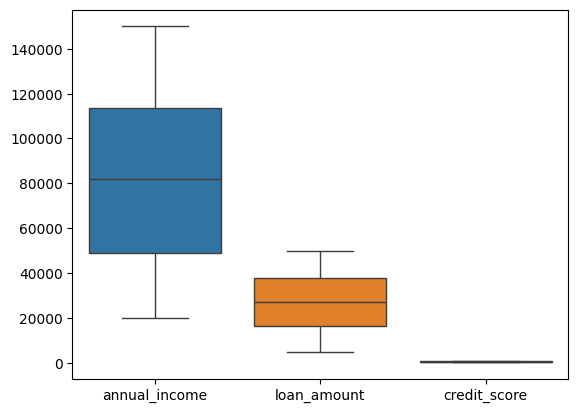

In [81]:
sns.boxplot(df_loan[['annual_income','loan_amount','credit_score']]) #no outliers to deal with

In [82]:
df_loan.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


## Column Transformer

In [83]:
from sklearn.compose import ColumnTransformer

In [97]:
transformer=ColumnTransformer(transformers=[('tnf1',StandardScaler(),['age','annual_income','loan_amount','credit_score']),
                                            ('tnf2',OrdinalEncoder(categories=[['Unemployed','Self-employed','Employed']]),['employment_status']),
                                            ('tnf3',OneHotEncoder(drop='first',sparse_output=False),['gender','marital_status'])],remainder='passthrough')

In [98]:
X_train,X_test,Y_train,Y_test=train_test_split(df_loan.drop('loan_approved',axis=1),df_loan['loan_approved'],test_size=0.2,random_state=2)

In [100]:
X_train_trans=transformer.fit_transform(X_train)

In [101]:
X_test_trans=transformer.transform(X_test)

In [102]:
X_train_trans.shape

(800, 10)

In [103]:
X_test_trans.shape

(200, 10)

## Model selection and training

In [104]:
from sklearn.linear_model import LogisticRegression

In [105]:
lr=LogisticRegression()

In [107]:
lr.fit(X_train_trans,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [108]:
y_pred=lr.predict(X_test_trans)

In [114]:
y_pred #predicted values

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0], dtype=int64)

## Checking the accuracy of the model

In [110]:
from sklearn.metrics import accuracy_score

In [113]:
accuracy_score(Y_test,y_pred)*100 #we are getting 88% accurate model

88.0